In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Set plot style for professional visualizations
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [2]:
# Load the dataset
df = pd.read_csv('..\datasets\iris.csv')

# Display the first few rows to understand the feature scales and target classes
display(df.head())

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
X = df.drop(columns=['species'])
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

Training samples: 120, Testing samples: 30


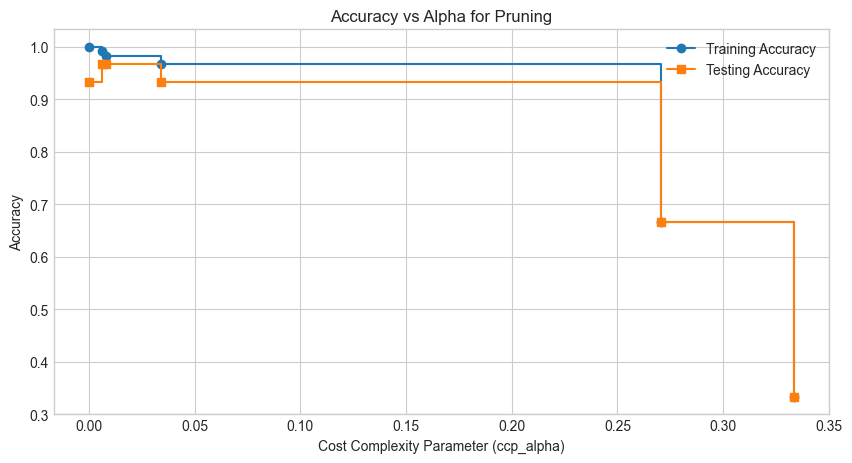

Optimal ccp_alpha selected: 0.0063


In [4]:
# Train initial unpruned tree to get alpha values
initial_tree = DecisionTreeClassifier(random_state=42)
path = initial_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Train a series of trees using the different alpha values
trees = []
for ccp_alpha in ccp_alphas:
    tree = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    tree.fit(X_train, y_train)
    trees.append(tree)

# Evaluate accuracies for both sets across all alphas
train_scores = [accuracy_score(y_train, tree.predict(X_train)) for tree in trees]
test_scores = [accuracy_score(y_test, tree.predict(X_test)) for tree in trees]

# Plot Accuracy vs. Alpha
plt.figure(figsize=(10, 5))
plt.plot(ccp_alphas, train_scores, marker='o', label='Training Accuracy', drawstyle='steps-post')
plt.plot(ccp_alphas, test_scores, marker='s', label='Testing Accuracy', drawstyle='steps-post')
plt.xlabel('Cost Complexity Parameter (ccp_alpha)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Alpha for Pruning')
plt.legend()
plt.show()

# Select the alpha that provides the highest testing accuracy
best_alpha = ccp_alphas[np.argmax(test_scores)]
print(f"Optimal ccp_alpha selected: {best_alpha:.4f}")

In [5]:
# Train final pruned model
pruned_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
pruned_tree.fit(X_train, y_train)
y_pred = pruned_tree.predict(X_test)

# Calculate Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
# Use 'weighted' average for multi-class F1-score
f1 = f1_score(y_test, y_pred, average='weighted') 

print("--- Final Pruned Model Performance ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1-Score:  {f1:.4f}\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

--- Final Pruned Model Performance ---
Accuracy:  0.9667
F1-Score:  0.9666

Detailed Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



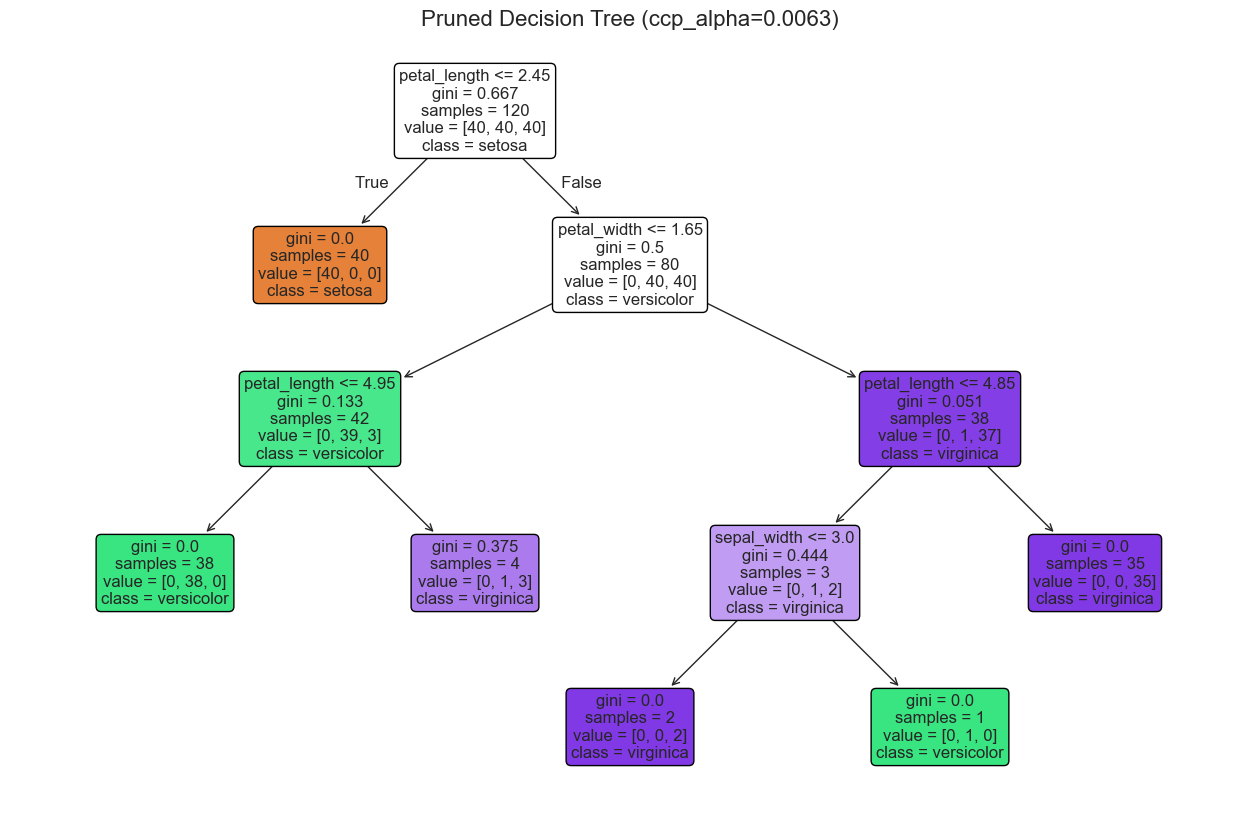

In [6]:
plt.figure(figsize=(16, 10))
plot_tree(
    pruned_tree, 
    feature_names=X.columns, 
    class_names=np.unique(y), 
    filled=True, 
    rounded=True, 
    fontsize=12
)
plt.title(f'Pruned Decision Tree (ccp_alpha={best_alpha:.4f})', fontsize=16)
plt.show()